# **Gestión de Proyectos**

---
---
<!-- Star Wars: Episodio II - El ataque de los clones -->


<!-- script html for image -->
<figure>
<center>

<img src='https://upload.wikimedia.org/wikipedia/commons/2/22/Star_Wars_Episode_VIII_The_Last_Jedi_Word_Logo.svg' width="500" height="300" />

</figure> </center>


Fuente de la imagen: [https://es.wikipedia.org](https://es.wikipedia.org/wiki/Star_Wars:_Episodio_VIII_-_Los_%C3%BAltimos_Jedi)



# **Índice**

---

> [Gestión de Proyectos](#scrollTo=tXPVxzqdGgiZ)
<br>
>>
>> [0 - Target ](#scrollTo=uaEvGBdwGgib&line=1&uniqifier=1)
>>
>> [1 - Análisis de anomalías (Outliers)](#scrollTo=YonoHT9ZGgic)
>>
>> [2 - Creación del Modelo ](#scrollTo=jkBm271zGgim&line=1&uniqifier=1)
>>
>> [3 - Anomalías ](#scrollTo=WLEbIFJJGgin)
>>
>> [4 - Más ejemplos de Outlier ](#scrollTo=YVSZ9FTZGgiq)
>>
>> [5 - Referencias ](#scrollTo=qS47C7GQGgit)
>

## O - Target:

1. Entender que son los Outliers (anomalias).

2. Saber analizarlos.

## 1 - Análisis de anomalias (Outliers)

Conocer los cuantiles condicionales de la variable respuesta permite identificar observaciones que se alejan atípicamente por encima o por debajo del valor esperado, para un determinado valor de los predictores. 

<img src="https://github.com/pifparfait/IL3/blob/main/Out1.png?raw=true" style="max-width:100%;"/>



A continuación, véase el siguiente ejemplo en el que se trata de identificar precios anómalos de diamantes.
<img src="https://github.com/pifparfait/IL3/blob/main/Out2.png?raw=true" style="max-width:100%;"/>


In [ ]:
!pip install skranger

     |████████████████████████████████| 440kB 4.1MB/s 
     |████████████████████████████████| 22.3MB 130kB/s 
  Found existing installation: scikit-learn 0.22.2.post1
    Uninstalling scikit-learn-0.22.2.post1:
      Successfully uninstalled scikit-learn-0.22.2.post1


In [ ]:
# Librerías
%config InlineBackend.figure_format = 'svg' # Para pintar las graficas en muy buena resolución
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from skranger.ensemble import RangerForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import OneHotEncoder
import multiprocessing


In [ ]:
# Datos
datos = sns.load_dataset("diamonds")

datos = datos[datos.cut.isin(["Fair", "Good"])]
datos['cut'] = datos['cut'].cat.remove_unused_categories()
datos['price'] = np.sqrt(datos['price'])
#datos = datos[['precio', 'corte', 'color', 'carat']]
datos.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6516 entries, 2 to 53936
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    6516 non-null   float64 
 1   cut      6516 non-null   category
 2   color    6516 non-null   category
 3   clarity  6516 non-null   category
 4   depth    6516 non-null   float64 
 5   table    6516 non-null   float64 
 6   price    6516 non-null   float64 
 7   x        6516 non-null   float64 
 8   y        6516 non-null   float64 
 9   z        6516 non-null   float64 
dtypes: category(3), float64(7)
memory usage: 427.2 KB


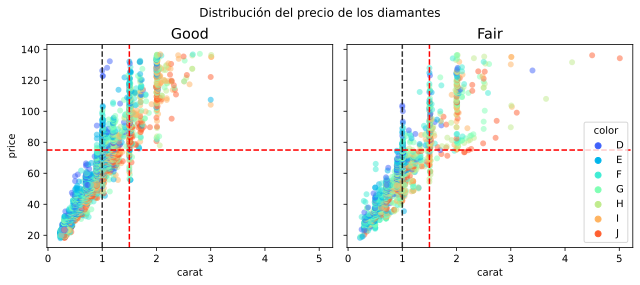

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), sharex=True,sharey=True)

for i, cut in enumerate(set(datos['cut'])):
    sns.scatterplot(
        x         = "carat",
        y         = "price",
        hue       = "color",
        palette   = "rainbow",
        linewidth = 0,
        alpha     = 0.5,
        data      = datos[datos.cut==cut],
        ax        = ax[i]
    )
    ax[i].set_title(cut, fontsize  = 'x-large')
    ax[i].axvline(x=1, linestyle   ='--',  color='black',alpha=0.8)
    ax[i].axvline(x=1.5, linestyle ='--',  color='red')
    ax[i].axhline(y=75, linestyle  ='--',  color='red')

ax[0].get_legend().remove()
fig.tight_layout()
plt.subplots_adjust(top = 0.85)
fig.suptitle('Distribución del precio de los diamantes', fontsize = 12);

 se puede observar que entre el intervalo 1 y 1,5 los precios cambian consideradeblemente.

In [ ]:
# Anomalías simuladas
anomalias_1 = datos.sample(frac=0.005, random_state=12345).copy()
anomalias_1['price'] = anomalias_1['price']*2.5

anomalias_2 = datos.sample(frac=0.005, random_state=12345).copy()
anomalias_2['price'] = anomalias_2['price']/2.5

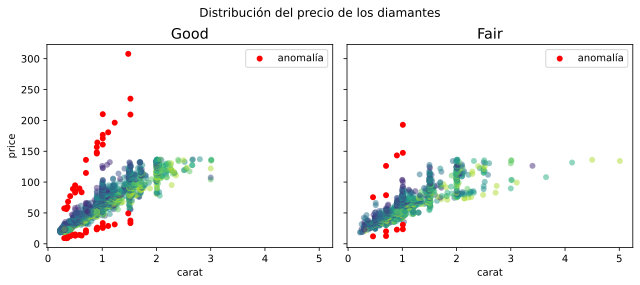

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), sharex=True,sharey=True)

for i, cut in enumerate(set(datos['cut'])):
    sns.scatterplot(
        x         = "carat",
        y         = "price",
        hue       = "color",
        palette   = "viridis",
        linewidth = 0,
        alpha     = 0.5,
        data      = datos[datos.cut==cut],
        legend    = False,
        ax        = ax[i]
    )
    sns.scatterplot(
        x         = "carat",
        y         = "price",
        color     = "red",
        linewidth = 0,
        alpha     = 1,
        data      = anomalias_1[anomalias_1.cut==cut],
        ax        = ax[i]
    )
    
    sns.scatterplot(
        x         = "carat",
        y         = "price",
        color     = "red",
        linewidth = 0,
        alpha     = 1,
        data      = anomalias_2[anomalias_2.cut==cut],
        label     = 'anomalía',
        ax        = ax[i]
    )
    ax[i].set_title(cut, fontsize = 'x-large')
    
fig.tight_layout()
plt.subplots_adjust(top = 0.85)
fig.suptitle('Distribución del precio de los diamantes', fontsize = 12);

In [ ]:
# Se añaden anomalías al set de datos
datos["anomalia"]       = False
anomalias_1["anomalia"] = True
anomalias_2["anomalia"] = True
datos = pd.concat([datos, anomalias_1, anomalias_2]).reset_index(drop=True)
datos.head()


,carat,cut,color,clarity,depth,table,price,x,y,z,anomalia
0,0.23,Good,E,VS1,56.9,65.0,18.083141,4.05,4.07,2.31,False
1,0.31,Good,J,SI2,63.3,58.0,18.303005,4.34,4.35,2.75,False
2,0.22,Fair,E,VS2,65.1,61.0,18.357560,3.87,3.78,2.49,False
3,0.30,Good,J,SI1,64.0,55.0,18.411953,4.25,4.28,2.73,False
4,0.30,Good,J,SI1,63.4,54.0,18.734994,4.23,4.29,2.70,False


**Después de analizar los datos y ver los outliers, podemos construir el modelo.**

## 2 - Creación del modelo

Se hace **one-hot-encoding** de las columnas cualitativas. Para mantener las columnas a las que no se les aplica ninguna transformación se tiene que indicar *remainder='passthrough'.*

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_selector

cat_cols = datos.select_dtypes(include=['object', 'category']).columns.to_list()

preprocessor = ColumnTransformer(
                   [('onehot', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
                   remainder='passthrough'
               )

X_train_prep = preprocessor.fit_transform(
                   datos.drop(columns=['price', 'anomalia'])
               )

modelo = RangerForestRegressor(
    n_estimators  = 5000,
    min_node_size = 300,
    max_depth     = 3,
    quantiles     = True,
)

modelo.fit(
    X=X_train_prep,
    y=datos.price
)


RangerForestRegressor(max_depth=3, min_node_size=300, n_estimators=5000,
                      quantiles=True)

<br>
<p> <mark>SABÍAS QUE...</mark> </p>
<hr>

"One-hot-encoding" es una manera de llamar a las [variables ficticias o variables dummy](https://en.wikipedia.org/wiki/Dummy_variable_(statistics))


## 3 - Anomalías

Se identifica como anomalías aquellos diamantes con un precio por debajo del percentil del 2% o por encima del percentil del 98% predichos por el modelo.



In [ ]:
# Se predicen los cuantiles para cada valor observado
pred_cuantiles = modelo.predict_quantiles(X=X_train_prep, quantiles=[0.01, 0.99])
pred_cuantiles = pd.DataFrame(pred_cuantiles.transpose(), columns=['q_01', 'q_99'])

# Se identifican las observaciones cuyo valor real está fuera del intervalo
datos = pd.concat([datos.reset_index(), pred_cuantiles], axis=1)
datos['fuera_intervalo'] = ~datos.price.between(datos.q_01, datos.q_99)


In [ ]:
data      = datos[(datos.cut==cut) & (datos.fuera_intervalo==True)],
data

(      index  carat   cut  ...       q_01        q_99  fuera_intervalo
 2         2   0.22  Fair  ...  19.000000   90.635623             True
 6519   6519   0.90  Fair  ...  24.939928  133.431630             True
 6527   6527   0.70  Fair  ...  19.849433  102.538480             True
 6530   6530   1.01  Fair  ...  24.999399  129.191446             True
 6542   6542   1.01  Fair  ...  26.256152  130.778439             True
 6552   6552   0.90  Fair  ...  24.939928  133.431630             True
 6558   6558   0.70  Fair  ...  19.973729  116.198107             True
 6563   6563   1.01  Fair  ...  24.999399  129.191446             True
 6566   6566   0.46  Fair  ...  18.894444   93.473660             True
 
 [9 rows x 15 columns],)

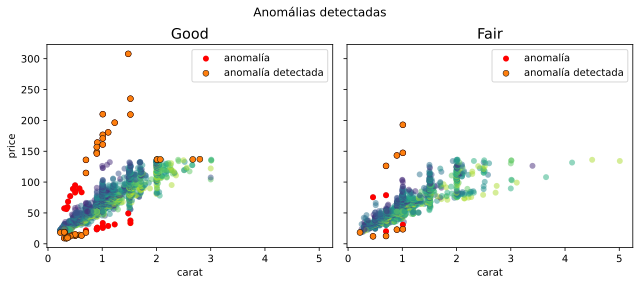

In [ ]:

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), sharex=True,sharey=True)

for i, cut in enumerate(set(datos['cut'])):
    sns.scatterplot(
        x         = "carat",
        y         = "price",
        hue       = "color",
        palette   = "viridis",
        linewidth = 0,
        alpha     = 0.5,
        data      = datos[datos.cut==cut],
        legend    = False,
        ax        = ax[i]
    )
    sns.scatterplot(
        x         = "carat",
        y         = "price",
        color     = "red",
        linewidth = 0,
        alpha     = 1,
        data      = anomalias_1[anomalias_1.cut==cut],
        ax        = ax[i]
    )
    
    sns.scatterplot(
        x         = "carat",
        y         = "price",
        color     = "red",
        linewidth = 0,
        alpha     = 1,
        data      = anomalias_2[anomalias_2.cut==cut],
        label     = 'anomalía',
        ax        = ax[i]
    )
    sns.scatterplot(
        x         = "carat",
        y         = "price",
        edgecolor = 'black',
        alpha     = 1,
        data      =  datos[(datos.cut==cut) & (datos.fuera_intervalo==True)],
        label     = 'anomalía detectada',
        ax        = ax[i]
    )
    
    
    ax[i].set_title(cut, fontsize = 'x-large')

#ax[1].get_legend().remove()
fig.tight_layout()
plt.subplots_adjust(top = 0.85)
fig.suptitle('Anomálias detectadas', fontsize = 12);



In [ ]:
# Anomalías reales vs anomalías detectadas

pd.crosstab(
    index   = datos["anomalia"], 
    columns = datos["fuera_intervalo"],
    margins = False
)


fuera_intervalo,False,True
anomalia,,
False,6506,10
True,30,36


## 4 - Más ejemplos de Outlier

Ahora para el campo de la estadística, veamos el siguiente ejemplo:

In [ ]:
import numpy as np
from sklearn.datasets import make_regression

#
# Generación de datos
#
rng = np.random.RandomState(0)
X, y = make_regression(
    n_samples=20,
    n_features=1,
    random_state=0,
    noise=4.0,
    bias=100.0,
)

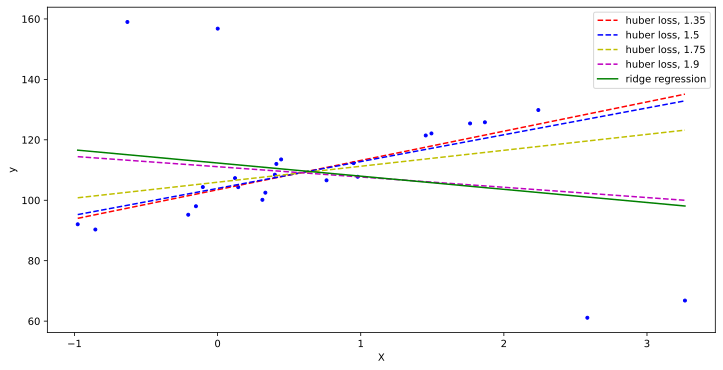

In [ ]:
#Creamos los outliers
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor, Ridge

# Adiciona cuatro outliers fuertes al dataset
X_outliers = rng.normal(0, 0.5, size=(4, 1))
y_outliers = rng.normal(0, 2.0, size=4)

X_outliers[:2, :] += X.max() + X.mean() / 4.0
X_outliers[2:, :] += X.min() - X.mean() / 4.0

y_outliers[:2] += y.min() - y.mean() / 4.0
y_outliers[2:] += y.max() + y.mean() / 4.0

X = np.vstack((X, X_outliers))
y = np.concatenate((y, y_outliers))

plt.figure(figsize=(12, 6))
plt.plot(X, y, "b.")
#Generamos el modelo de regresión de Huber
# Colores dependiendo de los parámetros de la función de
# error de Huber
colors = ["r--", "b--", "y--", "m--"]

x = np.linspace(X.min(), X.max(), 7)
epsilon_values = [1.35, 1.5, 1.75, 1.9]
for k, epsilon in enumerate(epsilon_values):
    huber = HuberRegressor(
        fit_intercept=True,
        alpha=0.0,
        max_iter=100,
        epsilon=epsilon,
    )
    huber.fit(X, y)
    coef_ = huber.coef_ * x + huber.intercept_
    plt.plot(x, coef_, colors[k], label="huber loss, %s" % epsilon)

# Creamos el modelo de Ridge regression
ridge = Ridge(
    fit_intercept=True,
    alpha=0.0,
    random_state=0,
    normalize=True,
)
ridge.fit(X, y)
coef_ridge = ridge.coef_
coef_ = ridge.coef_ * x + ridge.intercept_
plt.plot(x, coef_, "g-", label="ridge regression")


plt.xlabel("X")
plt.ylabel("y")
plt.legend(loc=0)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model

def metrics(m,X,y):
    yhat = m.predict(X)
    print(yhat)
    SS_Residual = sum((y-yhat)**2)
    SS_Total = sum((y-np.mean(y))**2)
    r_squared = 1 - (float(SS_Residual))/SS_Total
    adj_r_squared = 1 - (1-r_squared)*(len(y)-1)/(len(y)-X.shape[1]-1)
    return r_squared,adj_r_squared
    
data = pd.DataFrame({"x1": [1,2,3,4,5], "x2": [2.1,4,6.1,8,10.1]})
y = np.array([2.1, 4, 6.2, 8, 9])
model1 = linear_model.LinearRegression()
model1.fit( data.drop("x2", axis = 1),y)
metrics(model1,data.drop("x2", axis=1),y)

model2 = linear_model.LinearRegression()
model2.fit( data,y)
metrics(model2,data,y)

data = pd.DataFrame({"x1": [1,2,3,4,5], "x2": [2.1,4,6.1,8,10.1]} )
y = np.array([2.1, 4, 6.2, 8, 9])
model3 = linear_model.LinearRegression()
model3.fit( data,y)
metrics(model3,data,y)

[2.3  4.08 5.86 7.64 9.42]
[2.20666667 4.22       5.76666667 7.78       9.32666667]
[2.20666667 4.22       5.76666667 7.78       9.32666667]


(0.9874761549307456, 0.9749523098614912)

In [ ]:
!pip3 install -U nltk

     |████████████████████████████████| 1.5MB 4.2MB/s 
  Found existing installation: nltk 3.2.5
    Uninstalling nltk-3.2.5:
      Successfully uninstalled nltk-3.2.5


In [ ]:
from nltk.translate.bleu_score import sentence_bleu
reference = [['the', 'cat',"is","sitting","on","the","mat"]]
candidate = ["on",'the',"mat","is","a","cat"]
score = sentence_bleu(  reference, candidate)
print(score)


from nltk.translate.bleu_score import sentence_bleu
reference = [['the', 'cat',"is","sitting","on","the","mat"]]
candidate = ["there",'is',"cat","sitting","cat"]
score = sentence_bleu(  reference, candidate)
print(score)

5.5546715329196825e-78
1.0748016968157982e-231


/usr/local/lib/python3.7/dist-packages/nltk/translate/bleu_score.py:516: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.7/dist-packages/nltk/translate/bleu_score.py:516: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.7/dist-packages/nltk/translate/bleu_score.py:516: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg

## 5 - Referencias

Se recomienda leer las siguientes referencias:

1. https://machinelearningmastery.com/

2. https://blog.minitab.com/en/adventures-in-statistics-2/regression-analysis-how-do-i-interpret-r-squared-and-assess-the-goodness-of-fit

3. https://jdvelasq.github.io/courses/index.html

4. https://scikit-learn.org/stable/auto_examples/linear_model/plot_huber_vs_ridge.html#sphx-glr-auto-examples-linear-model-plot-huber-vs-ridge-py